<a href="https://colab.research.google.com/github/aniket-alt/CMPE-258-Deep-Learning/blob/main/Assignment%20-%204/3_advanced_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 3: Advanced Keras Deep Learning Customizations
## Building Custom Components from Scratch

---

**Author:** Aniket Patole  
**Course:** CMPE 258 - Deep Learning  
**Assignment:** Advanced Customizations in Deep Learning and Neural Networks

---

### Objective

This notebook demonstrates how to build custom components in TensorFlow/Keras, giving you complete control over your deep learning models. We'll implement:

1. **Custom Learning Rate Schedulers** - OneCycleLR and other schedulers
2. **Custom Dropout Layers** - MC Alpha Dropout for uncertainty estimation
3. **Custom Normalization** - MaxNorm Dense layers
4. **Custom Loss Functions** - Huber Loss and others
5. **Custom Activation Functions** - Parametric activations
6. **Custom Initializers** - Custom weight initialization
7. **Custom Constraints** - Weight constraints
8. **Custom Metrics** - Huber Metric and others
9. **Custom Layers** - Dense variants, Gaussian Noise, Layer Normalization
10. **Custom Models** - Residual Networks with custom blocks
11. **Custom Optimizers** - Momentum optimizer from scratch
12. **TensorBoard Integration** - Visualizing training progress

### Why Custom Components?

- **Research**: Implement new architectures from papers
- **Flexibility**: Tailor components to specific problems
- **Understanding**: Deep knowledge of how things work internally
- **Performance**: Optimize for specific use cases

---

## Part A: Setup and Imports

We import TensorFlow, Keras, and supporting libraries. We'll use the California Housing dataset for regression tasks and Fashion-MNIST for classification tasks to demonstrate our custom components.

In [ ]:
# Core imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import Callback, TensorBoard
from tensorflow.keras.constraints import Constraint
from tensorflow.keras.initializers import Initializer
from tensorflow.keras.regularizers import Regularizer
import datetime
import os
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Loading Datasets

We load two datasets:
1. **California Housing** - For regression tasks (predicting house prices)
2. **Fashion-MNIST** - For classification tasks (classifying clothing items)

This allows us to demonstrate custom components for both regression and classification.

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load California Housing dataset for regression
housing = fetch_california_housing()
X_housing, y_housing = housing.data, housing.target

# Split and scale
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)
X_train_h, X_val_h, y_train_h, y_val_h = train_test_split(
    X_train_h, y_train_h, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_h = scaler.fit_transform(X_train_h)
X_val_h = scaler.transform(X_val_h)
X_test_h = scaler.transform(X_test_h)

print("California Housing Dataset (Regression):")
print(f"  Training: {X_train_h.shape}, Validation: {X_val_h.shape}, Test: {X_test_h.shape}")

# Load Fashion-MNIST for classification
(X_train_f, y_train_f), (X_test_f, y_test_f) = keras.datasets.fashion_mnist.load_data()
X_train_f = X_train_f.astype('float32') / 255.0
X_test_f = X_test_f.astype('float32') / 255.0
X_train_f = X_train_f.reshape(-1, 784)
X_test_f = X_test_f.reshape(-1, 784)

# Create validation split
X_train_f, X_val_f = X_train_f[:50000], X_train_f[50000:]
y_train_f, y_val_f = y_train_f[:50000], y_train_f[50000:]

print("\nFashion-MNIST Dataset (Classification):")
print(f"  Training: {X_train_f.shape}, Validation: {X_val_f.shape}, Test: {X_test_f.shape}")

California Housing Dataset (Regression):
  Training: (13209, 8), Validation: (3303, 8), Test: (4128, 8)
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Fashion-MNIST Dataset (Classification):
  Training: (50000, 784), Validation: (10000, 784), Test: (10000, 784)


---

# Section 1: Custom Learning Rate Schedulers

## Concept

Learning rate schedulers adjust the learning rate during training. A well-designed schedule can significantly improve convergence and final performance.

**Popular schedulers:**
- **Step Decay**: Reduce LR at fixed intervals
- **Exponential Decay**: Continuously reduce LR
- **Cosine Annealing**: Smooth cosine-shaped decay
- **OneCycleLR**: Start low, increase to max, then decrease (super-convergence)

We'll implement a custom **OneCycleLR** scheduler, which has shown excellent results in practice.

---

### 1.1 Custom OneCycle Learning Rate Scheduler

The OneCycle policy starts with a low learning rate, increases to a maximum, then decreases to a very low value. This helps the model explore the loss landscape early and then fine-tune later.

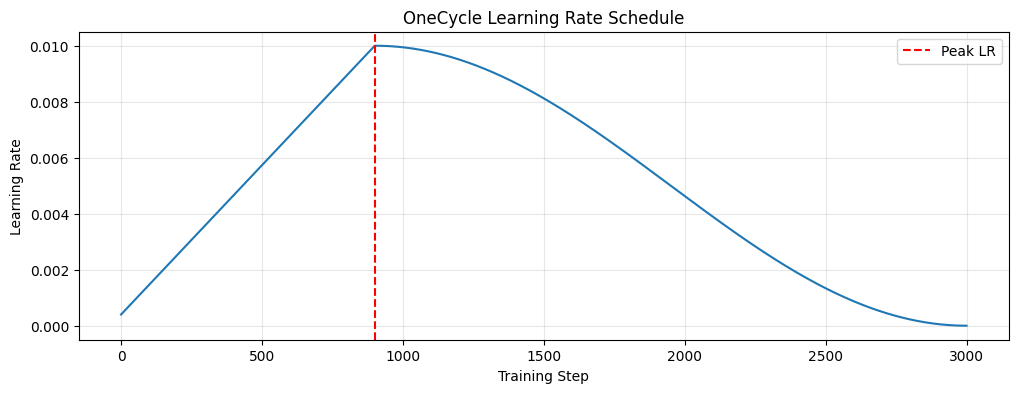

Initial LR: 0.000400
Max LR: 0.010000
Final LR: 0.0000000400


In [ ]:
class OneCycleLR(Callback):
    """
    OneCycle Learning Rate Scheduler.

    Implements the 1cycle policy from Leslie Smith's paper:
    - Phase 1: LR increases from initial_lr to max_lr
    - Phase 2: LR decreases from max_lr to initial_lr
    - Phase 3: LR decreases further to min_lr (annealing)

    Args:
        max_lr: Maximum learning rate
        steps_per_epoch: Number of batches per epoch
        epochs: Total number of epochs
        pct_start: Percentage of training spent increasing LR (default 0.3)
        div_factor: initial_lr = max_lr / div_factor (default 25)
        final_div_factor: min_lr = initial_lr / final_div_factor (default 1e4)
    """

    def __init__(self, max_lr, steps_per_epoch, epochs,
                 pct_start=0.3, div_factor=25.0, final_div_factor=1e4):
        super(OneCycleLR, self).__init__()
        self.max_lr = max_lr
        self.steps_per_epoch = steps_per_epoch
        self.epochs = epochs
        self.pct_start = pct_start
        self.div_factor = div_factor
        self.final_div_factor = final_div_factor

        self.total_steps = steps_per_epoch * epochs
        self.step_num = 0
        self.history = {'lr': []}

        # Calculate phase boundaries
        self.step_up = int(self.total_steps * pct_start)
        self.step_down = self.total_steps - self.step_up

        # Calculate learning rates
        self.initial_lr = max_lr / div_factor
        self.min_lr = self.initial_lr / final_div_factor

    def on_train_batch_begin(self, batch, logs=None):
        """Update learning rate at the beginning of each batch."""
        if self.step_num < self.step_up:
            # Phase 1: Linear increase
            lr = self.initial_lr + (self.max_lr - self.initial_lr) * (self.step_num / self.step_up)
        else:
            # Phase 2 & 3: Cosine annealing
            progress = (self.step_num - self.step_up) / self.step_down
            lr = self.min_lr + (self.max_lr - self.min_lr) * (1 + np.cos(np.pi * progress)) / 2

        # Keras 3 compatible way to set learning rate
        self.model.optimizer.learning_rate = lr
        self.history['lr'].append(lr)
        self.step_num += 1

    def on_epoch_end(self, epoch, logs=None):
        """Log current learning rate at end of epoch."""
        logs = logs or {}
        logs['lr'] = float(self.model.optimizer.learning_rate)


# Visualize the OneCycle schedule
steps_per_epoch = 100
epochs = 30
max_lr = 0.01

# Simulate the schedule
scheduler = OneCycleLR(max_lr=max_lr, steps_per_epoch=steps_per_epoch, epochs=epochs)
scheduler.total_steps = steps_per_epoch * epochs
scheduler.step_up = int(scheduler.total_steps * 0.3)
scheduler.step_down = scheduler.total_steps - scheduler.step_up

lrs = []
for step in range(scheduler.total_steps):
    if step < scheduler.step_up:
        lr = scheduler.initial_lr + (scheduler.max_lr - scheduler.initial_lr) * (step / scheduler.step_up)
    else:
        progress = (step - scheduler.step_up) / scheduler.step_down
        lr = scheduler.min_lr + (scheduler.max_lr - scheduler.min_lr) * (1 + np.cos(np.pi * progress)) / 2
    lrs.append(lr)

plt.figure(figsize=(12, 4))
plt.plot(lrs)
plt.xlabel('Training Step')
plt.ylabel('Learning Rate')
plt.title('OneCycle Learning Rate Schedule')
plt.axvline(x=scheduler.step_up, color='r', linestyle='--', label='Peak LR')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial LR: {scheduler.initial_lr:.6f}")
print(f"Max LR: {scheduler.max_lr:.6f}")
print(f"Final LR: {scheduler.min_lr:.10f}")

### 1.2 Custom Exponential Decay with Warmup

Another popular scheduler that starts with a warmup phase (gradually increasing LR) followed by exponential decay. This is commonly used in transformer training.

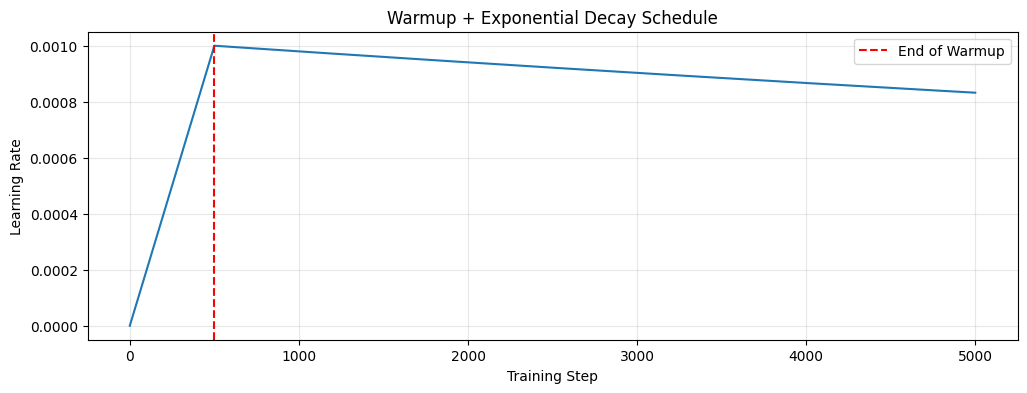

In [ ]:
class WarmupExponentialDecay(keras.optimizers.schedules.LearningRateSchedule):
    """
    Learning rate schedule with linear warmup and exponential decay.

    Args:
        initial_lr: Starting learning rate after warmup
        decay_steps: Number of steps for decay
        decay_rate: Decay multiplier
        warmup_steps: Number of warmup steps
    """

    def __init__(self, initial_lr, decay_steps, decay_rate, warmup_steps):
        super(WarmupExponentialDecay, self).__init__()
        self.initial_lr = initial_lr
        self.decay_steps = decay_steps
        self.decay_rate = decay_rate
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # Convert to float
        step = tf.cast(step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)

        # Warmup phase: linear increase
        warmup_lr = self.initial_lr * (step / warmup_steps)

        # Decay phase: exponential decay
        decay_lr = self.initial_lr * tf.pow(
            self.decay_rate,
            (step - warmup_steps) / self.decay_steps
        )

        # Return warmup LR if in warmup, else decay LR
        return tf.where(step < warmup_steps, warmup_lr, decay_lr)

    def get_config(self):
        return {
            'initial_lr': self.initial_lr,
            'decay_steps': self.decay_steps,
            'decay_rate': self.decay_rate,
            'warmup_steps': self.warmup_steps,
        }


# Visualize the warmup + decay schedule
schedule = WarmupExponentialDecay(
    initial_lr=0.001,
    decay_steps=1000,
    decay_rate=0.96,
    warmup_steps=500
)

steps = np.arange(0, 5000)
lrs = [schedule(step).numpy() for step in steps]

plt.figure(figsize=(12, 4))
plt.plot(steps, lrs)
plt.xlabel('Training Step')
plt.ylabel('Learning Rate')
plt.title('Warmup + Exponential Decay Schedule')
plt.axvline(x=500, color='r', linestyle='--', label='End of Warmup')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

# Section 2: Custom Dropout - MC Alpha Dropout

## Concept

**Alpha Dropout** is designed specifically for Self-Normalizing Neural Networks (SNNs) with SELU activation. Unlike standard dropout:

- It maintains the self-normalizing property of SELU
- Dropped values are set to the negative saturation value, not zero
- It preserves mean and variance of inputs

We implement **MC Alpha Dropout** which keeps dropout active during inference for Monte Carlo uncertainty estimation.

---

In [ ]:
class MCAlphaDropout(layers.Layer):
    """
    Monte Carlo Alpha Dropout Layer.

    Alpha Dropout is designed for SELU activation - it maintains
    the self-normalizing property by setting dropped units to
    the negative saturation value rather than zero.

    MC variant keeps dropout active during inference for
    uncertainty estimation via multiple forward passes.

    Args:
        rate: Dropout rate (probability of dropping)
    """

    def __init__(self, rate=0.1, **kwargs):
        super(MCAlphaDropout, self).__init__(**kwargs)
        self.rate = rate
        # Alpha dropout parameters for SELU
        self.alpha = 1.6732632423543772848170429916717
        self.scale = 1.0507009873554804934193349852946
        self.alpha_p = -self.alpha * self.scale

    def call(self, inputs, training=None):
        """
        Apply alpha dropout.

        Key difference from standard dropout:
        - Always applied (training=True forced for MC)
        - Dropped values set to alpha_p, not 0
        - Affine transformation to maintain mean/variance
        """
        # For MC Dropout, always apply dropout (ignore training flag)
        keep_prob = 1.0 - self.rate

        # Calculate affine transformation parameters
        a = (keep_prob + keep_prob * (1 - keep_prob) * self.alpha_p ** 2) ** -0.5
        b = -a * self.alpha_p * (1 - keep_prob)

        # Create dropout mask
        random_tensor = tf.random.uniform(tf.shape(inputs))
        keep_mask = tf.cast(random_tensor >= self.rate, inputs.dtype)

        # Apply alpha dropout
        # Kept units stay same, dropped units become alpha_p
        dropped = inputs * keep_mask + self.alpha_p * (1 - keep_mask)

        # Apply affine transformation to preserve mean/variance
        return a * dropped + b

    def get_config(self):
        config = super(MCAlphaDropout, self).get_config()
        config.update({'rate': self.rate})
        return config


# Demonstrate MC Alpha Dropout
print("MC Alpha Dropout Demonstration")
print("=" * 50)

# Create sample input
sample_input = tf.constant([[1.0, 2.0, 3.0, 4.0, 5.0]])

# Apply MC Alpha Dropout multiple times
mc_dropout = MCAlphaDropout(rate=0.3)

print(f"Original input: {sample_input.numpy()}")
print("\nMultiple MC Dropout passes:")
for i in range(5):
    output = mc_dropout(sample_input, training=True)
    print(f"  Pass {i+1}: {output.numpy().round(3)}")

print("\nNote: Each pass produces different outputs due to stochastic dropout.")
print("This enables uncertainty estimation via Monte Carlo sampling.")

MC Alpha Dropout Demonstration
Original input: [[1. 2. 3. 4. 5.]]

Multiple MC Dropout passes:
  Pass 1: [[-1.06   2.176  3.037  3.898  4.759]]
  Pass 2: [[-1.06   2.176  3.037 -1.06   4.759]]
  Pass 3: [[ 1.315 -1.06   3.037 -1.06   4.759]]
  Pass 4: [[ 1.315  2.176  3.037 -1.06  -1.06 ]]
  Pass 5: [[ 1.315 -1.06   3.037 -1.06   4.759]]

Note: Each pass produces different outputs due to stochastic dropout.
This enables uncertainty estimation via Monte Carlo sampling.


---

# Section 3: Custom Normalization - MaxNorm Dense

## Concept

**MaxNorm** is a weight constraint that limits the maximum norm of incoming weights to each neuron. This prevents weights from growing too large and acts as a form of regularization.

We implement a **MaxNormDense** layer that combines a Dense layer with built-in MaxNorm constraint.

---

In [ ]:
class MaxNormDense(layers.Layer):
    """
    Dense layer with MaxNorm weight constraint.

    MaxNorm constrains the weight vectors to have a maximum norm,
    which helps prevent overfitting and stabilizes training.

    Args:
        units: Number of output units
        max_norm: Maximum norm for weight vectors
        activation: Activation function
    """

    def __init__(self, units, max_norm=2.0, activation=None, **kwargs):
        super(MaxNormDense, self).__init__(**kwargs)
        self.units = units
        self.max_norm = max_norm
        self.activation = keras.activations.get(activation)

    def build(self, input_shape):
        """Create layer weights."""
        self.w = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):
        """
        Forward pass with MaxNorm constraint applied.

        The constraint is applied by clipping the norm of each
        weight vector (column) to max_norm.
        """
        # Apply MaxNorm constraint to weights
        norms = tf.norm(self.w, axis=0, keepdims=True)
        desired_norms = tf.clip_by_value(norms, 0, self.max_norm)
        constrained_w = self.w * (desired_norms / (norms + 1e-7))

        # Compute output
        output = tf.matmul(inputs, constrained_w) + self.b

        if self.activation is not None:
            output = self.activation(output)

        return output

    def get_config(self):
        config = super(MaxNormDense, self).get_config()
        config.update({
            'units': self.units,
            'max_norm': self.max_norm,
            'activation': keras.activations.serialize(self.activation)
        })
        return config


# Demonstrate MaxNormDense
print("MaxNormDense Layer Demonstration")
print("=" * 50)

# Create a simple model with MaxNormDense
model = keras.Sequential([
    layers.Input(shape=(10,)),
    MaxNormDense(64, max_norm=2.0, activation='relu'),
    MaxNormDense(32, max_norm=2.0, activation='relu'),
    MaxNormDense(1)
])

model.summary()

# Test forward pass
sample_input = tf.random.normal((2, 10))
output = model(sample_input)
print(f"\nInput shape: {sample_input.shape}")
print(f"Output shape: {output.shape}")

MaxNormDense Layer Demonstration


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ max_norm_dense_3 (MaxNormDense) │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_norm_dense_4 (MaxNormDense) │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_norm_dense_5 (MaxNormDense) │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)


Input shape: (2, 10)
Output shape: (2, 1)


---

# Section 4: Custom Loss Functions

## Concept

Custom loss functions allow you to optimize for specific objectives. We'll implement:

1. **Huber Loss** - Less sensitive to outliers than MSE
2. **Focal Loss** - Handles class imbalance in classification

---

### 4.1 Custom Huber Loss

Huber Loss combines MSE and MAE - it's quadratic for small errors (like MSE) and linear for large errors (like MAE). This makes it robust to outliers.

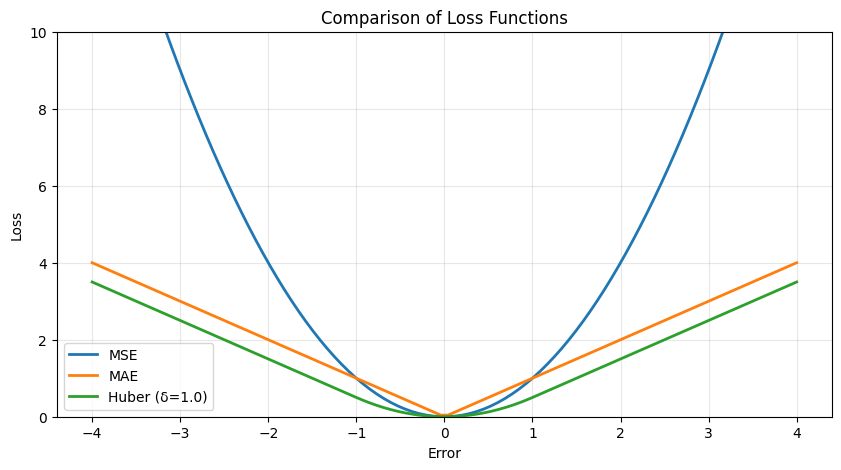

Huber Loss combines the best of both worlds:
  - Behaves like MSE for small errors (smooth gradient)
  - Behaves like MAE for large errors (robust to outliers)


In [ ]:
class HuberLoss(keras.losses.Loss):
    """
    Huber Loss - robust to outliers.

    For small errors (|error| <= delta): L = 0.5 * error^2
    For large errors (|error| > delta): L = delta * |error| - 0.5 * delta^2

    This is quadratic for small errors (like MSE) but linear for
    large errors (like MAE), providing robustness to outliers.

    Args:
        delta: Threshold where loss transitions from quadratic to linear
    """

    def __init__(self, delta=1.0, **kwargs):
        super(HuberLoss, self).__init__(**kwargs)
        self.delta = delta

    def call(self, y_true, y_pred):
        """Compute Huber loss."""
        error = y_true - y_pred
        abs_error = tf.abs(error)

        # Quadratic for small errors, linear for large errors
        quadratic = 0.5 * tf.square(error)
        linear = self.delta * abs_error - 0.5 * tf.square(self.delta)

        # Use quadratic where |error| <= delta, else linear
        loss = tf.where(abs_error <= self.delta, quadratic, linear)

        return tf.reduce_mean(loss)

    def get_config(self):
        config = super(HuberLoss, self).get_config()
        config.update({'delta': self.delta})
        return config


# Visualize Huber Loss vs MSE vs MAE
errors = np.linspace(-4, 4, 100)
delta = 1.0

mse_losses = errors ** 2
mae_losses = np.abs(errors)
huber_losses = np.where(
    np.abs(errors) <= delta,
    0.5 * errors ** 2,
    delta * np.abs(errors) - 0.5 * delta ** 2
)

plt.figure(figsize=(10, 5))
plt.plot(errors, mse_losses, label='MSE', linewidth=2)
plt.plot(errors, mae_losses, label='MAE', linewidth=2)
plt.plot(errors, huber_losses, label=f'Huber (δ={delta})', linewidth=2)
plt.xlabel('Error')
plt.ylabel('Loss')
plt.title('Comparison of Loss Functions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 10)
plt.show()

print("Huber Loss combines the best of both worlds:")
print("  - Behaves like MSE for small errors (smooth gradient)")
print("  - Behaves like MAE for large errors (robust to outliers)")

### 4.2 Custom Focal Loss

Focal Loss down-weights easy examples and focuses on hard-to-classify ones. This is especially useful for imbalanced datasets.

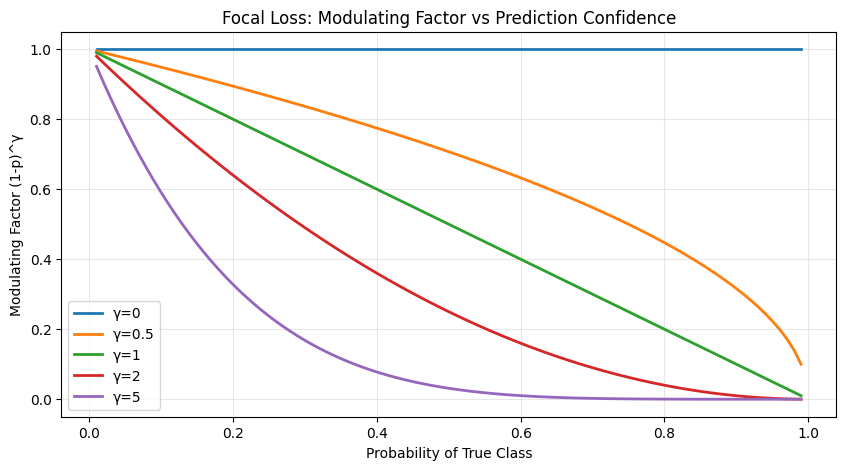

Higher gamma means more focus on hard examples (low p).
When γ=0, Focal Loss = Cross Entropy.


In [ ]:
class FocalLoss(keras.losses.Loss):
    """
    Focal Loss for handling class imbalance.

    FL(p) = -alpha * (1 - p)^gamma * log(p)

    The (1 - p)^gamma term down-weights easy examples (high p)
    and focuses learning on hard examples (low p).

    Args:
        gamma: Focusing parameter (higher = more focus on hard examples)
        alpha: Class balancing weight
    """

    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super(FocalLoss, self).__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        """Compute focal loss."""
        # Clip predictions for numerical stability
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        # Compute cross entropy
        cross_entropy = -y_true * tf.math.log(y_pred)

        # Compute focal weight
        focal_weight = self.alpha * tf.pow(1 - y_pred, self.gamma)

        # Focal loss
        focal_loss = focal_weight * cross_entropy

        return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=-1))

    def get_config(self):
        config = super(FocalLoss, self).get_config()
        config.update({'gamma': self.gamma, 'alpha': self.alpha})
        return config


# Visualize Focal Loss modulating factor
p = np.linspace(0.01, 0.99, 100)
gammas = [0, 0.5, 1, 2, 5]

plt.figure(figsize=(10, 5))
for gamma in gammas:
    modulating_factor = (1 - p) ** gamma
    plt.plot(p, modulating_factor, label=f'γ={gamma}', linewidth=2)

plt.xlabel('Probability of True Class')
plt.ylabel('Modulating Factor (1-p)^γ')
plt.title('Focal Loss: Modulating Factor vs Prediction Confidence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Higher gamma means more focus on hard examples (low p).")
print("When γ=0, Focal Loss = Cross Entropy.")

---

# Section 5: Custom Activation Functions

## Concept

Custom activations can be tailored to specific needs. We'll implement:

1. **Leaky ReLU** with custom slope
2. **Swish** (SiLU) activation
3. **Mish** activation

---

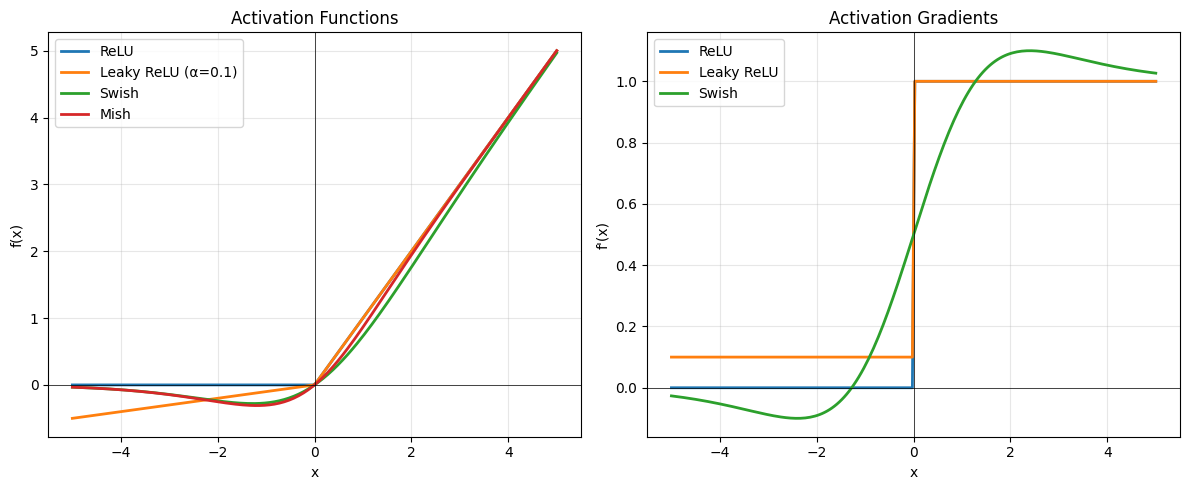

Key observations:
  - ReLU: Simple but 'dead neuron' problem (0 gradient for x<0)
  - Leaky ReLU: Fixes dead neuron issue with small negative slope
  - Swish/Mish: Smooth, non-monotonic, often work better in deep nets


In [ ]:
class LeakyReLU(layers.Layer):
    """
    Custom Leaky ReLU activation with configurable negative slope.

    f(x) = x if x > 0
    f(x) = alpha * x if x <= 0

    Args:
        alpha: Slope for negative values
    """

    def __init__(self, alpha=0.01, **kwargs):
        super(LeakyReLU, self).__init__(**kwargs)
        self.alpha = alpha

    def call(self, inputs):
        return tf.where(inputs > 0, inputs, self.alpha * inputs)

    def get_config(self):
        config = super(LeakyReLU, self).get_config()
        config.update({'alpha': self.alpha})
        return config


class Swish(layers.Layer):
    """
    Swish activation (also known as SiLU).

    f(x) = x * sigmoid(beta * x)

    Swish is smooth, non-monotonic, and has shown good results
    in deep networks. It's the default activation in EfficientNet.

    Args:
        beta: Scaling parameter (1.0 = standard Swish)
    """

    def __init__(self, beta=1.0, **kwargs):
        super(Swish, self).__init__(**kwargs)
        self.beta = beta

    def call(self, inputs):
        return inputs * tf.nn.sigmoid(self.beta * inputs)

    def get_config(self):
        config = super(Swish, self).get_config()
        config.update({'beta': self.beta})
        return config


class Mish(layers.Layer):
    """
    Mish activation function.

    f(x) = x * tanh(softplus(x))
    f(x) = x * tanh(ln(1 + e^x))

    Mish is smooth and non-monotonic, similar to Swish but with
    different characteristics that can work better in some cases.
    """

    def __init__(self, **kwargs):
        super(Mish, self).__init__(**kwargs)

    def call(self, inputs):
        return inputs * tf.nn.tanh(tf.nn.softplus(inputs))


# Visualize activation functions
x = np.linspace(-5, 5, 200)

# Compute activations
relu = np.maximum(0, x)
leaky_relu = np.where(x > 0, x, 0.1 * x)
swish = x * 1 / (1 + np.exp(-x))
mish = x * np.tanh(np.log(1 + np.exp(x)))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x, relu, label='ReLU', linewidth=2)
plt.plot(x, leaky_relu, label='Leaky ReLU (α=0.1)', linewidth=2)
plt.plot(x, swish, label='Swish', linewidth=2)
plt.plot(x, mish, label='Mish', linewidth=2)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Activation Functions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)

# Compute derivatives
plt.subplot(1, 2, 2)
relu_grad = np.where(x > 0, 1, 0)
leaky_grad = np.where(x > 0, 1, 0.1)
sigmoid = 1 / (1 + np.exp(-x))
swish_grad = sigmoid + x * sigmoid * (1 - sigmoid)

plt.plot(x, relu_grad, label='ReLU', linewidth=2)
plt.plot(x, leaky_grad, label='Leaky ReLU', linewidth=2)
plt.plot(x, swish_grad, label='Swish', linewidth=2)
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.title('Activation Gradients')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

print("Key observations:")
print("  - ReLU: Simple but 'dead neuron' problem (0 gradient for x<0)")
print("  - Leaky ReLU: Fixes dead neuron issue with small negative slope")
print("  - Swish/Mish: Smooth, non-monotonic, often work better in deep nets")

---

# Section 6: Custom Initializers

## Concept

Weight initialization is crucial for training deep networks. We'll implement:

1. **Custom Glorot Initializer** with configurable parameters
2. **Orthogonal Initializer** for RNNs

---

In [ ]:
class MyGlorotInitializer(Initializer):
    """
    Custom Glorot (Xavier) Initializer.

    Draws weights from a distribution with variance:
    Var(W) = 2 / (fan_in + fan_out)

    This helps maintain gradient variance across layers.

    Args:
        seed: Random seed for reproducibility
    """

    def __init__(self, seed=None):
        self.seed = seed

    def __call__(self, shape, dtype=None):
        """Generate initialized weights."""
        dtype = dtype or tf.float32

        # Calculate fan_in and fan_out
        if len(shape) == 2:
            fan_in, fan_out = shape[0], shape[1]
        elif len(shape) >= 3:
            receptive_field = np.prod(shape[:-2])
            fan_in = shape[-2] * receptive_field
            fan_out = shape[-1] * receptive_field
        else:
            fan_in = fan_out = shape[0]

        # Glorot uniform bounds
        limit = np.sqrt(6.0 / (fan_in + fan_out))

        return tf.random.uniform(
            shape, -limit, limit, dtype=dtype, seed=self.seed
        )

    def get_config(self):
        return {'seed': self.seed}


class OrthogonalInitializer(Initializer):
    """
    Orthogonal Initializer - great for RNNs.

    Creates orthogonal matrices which preserve gradient magnitude
    during backpropagation, helping with vanishing/exploding gradients.

    Args:
        gain: Multiplicative factor for the orthogonal matrix
        seed: Random seed
    """

    def __init__(self, gain=1.0, seed=None):
        self.gain = gain
        self.seed = seed

    def __call__(self, shape, dtype=None):
        """Generate orthogonal weights via QR decomposition."""
        dtype = dtype or tf.float32

        if self.seed is not None:
            np.random.seed(self.seed)

        # Flatten to 2D
        num_rows = shape[0]
        num_cols = np.prod(shape[1:])
        flat_shape = (max(num_rows, num_cols), min(num_rows, num_cols))

        # Generate random matrix and compute QR decomposition
        random_matrix = np.random.randn(*flat_shape)
        q, r = np.linalg.qr(random_matrix)

        # Make Q uniform (remove sign ambiguity)
        d = np.diag(r)
        q *= np.sign(d)

        # Reshape and scale
        if num_rows < num_cols:
            q = q.T
        q = q[:num_rows, :num_cols]
        q = q.reshape(shape)

        return tf.constant(self.gain * q, dtype=dtype)

    def get_config(self):
        return {'gain': self.gain, 'seed': self.seed}


# Demonstrate custom initializers
print("Custom Initializers Demonstration")
print("=" * 50)

shape = (5, 5)

# Glorot
glorot_init = MyGlorotInitializer(seed=42)
glorot_weights = glorot_init(shape)
print(f"\nGlorot Initialized Weights ({shape}):")
print(f"  Mean: {tf.reduce_mean(glorot_weights):.4f}")
print(f"  Std:  {tf.math.reduce_std(glorot_weights):.4f}")

# Orthogonal
ortho_init = OrthogonalInitializer(seed=42)
ortho_weights = ortho_init(shape)
print(f"\nOrthogonal Initialized Weights ({shape}):")
print(f"  Mean: {tf.reduce_mean(ortho_weights):.4f}")
print(f"  Std:  {tf.math.reduce_std(ortho_weights):.4f}")

# Verify orthogonality (W^T * W should be close to identity)
wtw = tf.matmul(ortho_weights, ortho_weights, transpose_a=True)
print(f"\nW^T * W (should be ~identity):")
print(wtw.numpy().round(3))

Custom Initializers Demonstration

Glorot Initialized Weights ((5, 5)):
  Mean: -0.1139
  Std:  0.4943

Orthogonal Initialized Weights ((5, 5)):
  Mean: 0.0608
  Std:  0.4431

W^T * W (should be ~identity):
[[ 1. -0. -0. -0.  0.]
 [-0.  1. -0.  0.  0.]
 [-0. -0.  1. -0. -0.]
 [-0.  0. -0.  1.  0.]
 [ 0.  0. -0.  0.  1.]]


---

# Section 7: Custom Weight Constraints

## Concept

Weight constraints limit the values of weights during training. We'll implement:

1. **PositiveWeights** - Forces all weights to be positive
2. **UnitNorm** - Normalizes weight vectors to unit length

---

In [ ]:
class PositiveWeights(Constraint):
    """
    Constraint that forces weights to be non-negative.

    Useful when you need weights to represent quantities
    that must be positive (e.g., attention scores before softmax).
    """

    def __call__(self, w):
        """Clip weights to be >= 0."""
        return tf.nn.relu(w)

    def get_config(self):
        return {}


class UnitNormConstraint(Constraint):
    """
    Constraint that normalizes weight vectors to unit length.

    Each column (or row, depending on axis) of the weight matrix
    is normalized to have L2 norm = 1.

    Args:
        axis: Axis along which to compute norms
    """

    def __init__(self, axis=0):
        self.axis = axis

    def __call__(self, w):
        """Normalize weights to unit norm."""
        return w / (tf.norm(w, axis=self.axis, keepdims=True) + 1e-7)

    def get_config(self):
        return {'axis': self.axis}


# Demonstrate constraints
print("Custom Weight Constraints Demonstration")
print("=" * 50)

# Sample weights with some negative values
sample_weights = tf.constant([[-1.0, 2.0], [0.5, -0.5], [1.0, 1.0]])
print(f"Original weights:\n{sample_weights.numpy()}")

# Apply PositiveWeights constraint
positive_constraint = PositiveWeights()
positive_weights = positive_constraint(sample_weights)
print(f"\nAfter PositiveWeights constraint:\n{positive_weights.numpy()}")

# Apply UnitNorm constraint
unitnorm_constraint = UnitNormConstraint(axis=0)
unitnorm_weights = unitnorm_constraint(sample_weights)
print(f"\nAfter UnitNorm constraint:\n{unitnorm_weights.numpy().round(3)}")

# Verify unit norm
norms = tf.norm(unitnorm_weights, axis=0)
print(f"\nColumn norms (should be 1): {norms.numpy().round(3)}")

Custom Weight Constraints Demonstration
Original weights:
[[-1.   2. ]
 [ 0.5 -0.5]
 [ 1.   1. ]]

After PositiveWeights constraint:
[[0.  2. ]
 [0.5 0. ]
 [1.  1. ]]

After UnitNorm constraint:
[[-0.667  0.873]
 [ 0.333 -0.218]
 [ 0.667  0.436]]

Column norms (should be 1): [1. 1.]


---

# Section 8: Custom Metrics

## Concept

Custom metrics let you track specific quantities during training. We'll implement:

1. **HuberMetric** - Tracks Huber loss as a metric
2. **F1Score** - Computes F1 score for classification

---

In [ ]:
class HuberMetric(keras.metrics.Metric):
    """
    Custom Huber Metric.

    Tracks the mean Huber loss across batches. Useful when you want
    to monitor Huber loss as a metric while using a different loss
    function for optimization.

    Args:
        delta: Threshold for Huber loss
    """

    def __init__(self, delta=1.0, name='huber_metric', **kwargs):
        super(HuberMetric, self).__init__(name=name, **kwargs)
        self.delta = delta
        # State variables to track running totals
        self.total = self.add_weight(name='total', initializer='zeros')
        self.count = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        """Update metric state with new batch."""
        error = y_true - y_pred
        abs_error = tf.abs(error)

        # Huber loss calculation
        quadratic = 0.5 * tf.square(error)
        linear = self.delta * abs_error - 0.5 * tf.square(self.delta)
        huber = tf.where(abs_error <= self.delta, quadratic, linear)

        # Update running totals
        batch_huber = tf.reduce_sum(huber)
        batch_count = tf.cast(tf.size(y_true), tf.float32)

        self.total.assign_add(batch_huber)
        self.count.assign_add(batch_count)

    def result(self):
        """Compute final metric value."""
        return self.total / self.count

    def reset_state(self):
        """Reset metric state at the start of each epoch."""
        self.total.assign(0.0)
        self.count.assign(0.0)

    def get_config(self):
        config = super(HuberMetric, self).get_config()
        config.update({'delta': self.delta})
        return config


class F1Score(keras.metrics.Metric):
    """
    F1 Score metric for binary classification.

    F1 = 2 * (precision * recall) / (precision + recall)

    Args:
        threshold: Classification threshold
    """

    def __init__(self, threshold=0.5, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.threshold = threshold
        self.true_positives = self.add_weight(name='tp', initializer='zeros')
        self.false_positives = self.add_weight(name='fp', initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        """Update confusion matrix counts."""
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred > self.threshold, tf.float32)

        tp = tf.reduce_sum(y_true * y_pred)
        fp = tf.reduce_sum((1 - y_true) * y_pred)
        fn = tf.reduce_sum(y_true * (1 - y_pred))

        self.true_positives.assign_add(tp)
        self.false_positives.assign_add(fp)
        self.false_negatives.assign_add(fn)

    def result(self):
        """Compute F1 score."""
        precision = self.true_positives / (self.true_positives + self.false_positives + 1e-7)
        recall = self.true_positives / (self.true_positives + self.false_negatives + 1e-7)
        return 2 * precision * recall / (precision + recall + 1e-7)

    def reset_state(self):
        self.true_positives.assign(0.0)
        self.false_positives.assign(0.0)
        self.false_negatives.assign(0.0)


# Demonstrate custom metrics
print("Custom Metrics Demonstration")
print("=" * 50)

# Huber Metric
huber_metric = HuberMetric(delta=1.0)
y_true = tf.constant([1.0, 2.0, 3.0, 4.0])
y_pred = tf.constant([1.1, 2.5, 2.8, 10.0])  # Last one is an outlier

huber_metric.update_state(y_true, y_pred)
print(f"Huber Metric value: {huber_metric.result().numpy():.4f}")
print(f"MSE for comparison: {tf.reduce_mean(tf.square(y_true - y_pred)).numpy():.4f}")
print("(Huber is less affected by the outlier)")

# F1 Score
f1_metric = F1Score(threshold=0.5)
y_true_bin = tf.constant([1, 0, 1, 1, 0, 1])
y_pred_bin = tf.constant([0.9, 0.1, 0.8, 0.4, 0.2, 0.7])

f1_metric.update_state(y_true_bin, y_pred_bin)
print(f"\nF1 Score: {f1_metric.result().numpy():.4f}")

Custom Metrics Demonstration
Huber Metric value: 1.4125
MSE for comparison: 9.0750
(Huber is less affected by the outlier)

F1 Score: 0.8571


---

# Section 9: Custom Layers

## Concept

Custom layers encapsulate reusable computations. We'll implement:

1. **ExponentialLayer** - Computes e^(w*x + b)
2. **MyDense** - Dense layer from scratch
3. **AddGaussianNoise** - Adds noise during training
4. **LayerNormalization** - Layer normalization from scratch

---

In [ ]:
class ExponentialLayer(layers.Layer):
    """
    Exponential transformation layer.

    Computes: output = exp(W * input + b)

    Useful when you need strictly positive outputs that can
    span multiple orders of magnitude.

    Args:
        units: Number of output units
    """

    def __init__(self, units, **kwargs):
        super(ExponentialLayer, self).__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.w = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )
        self.b = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):
        linear = tf.matmul(inputs, self.w) + self.b
        return tf.exp(linear)

    def get_config(self):
        config = super(ExponentialLayer, self).get_config()
        config.update({'units': self.units})
        return config


class MyDense(layers.Layer):
    """
    Custom Dense layer implemented from scratch.

    Demonstrates the fundamental building blocks of a fully
    connected layer: weights, biases, and optional activation.

    Args:
        units: Number of output units
        activation: Activation function
        use_bias: Whether to include bias
    """

    def __init__(self, units, activation=None, use_bias=True, **kwargs):
        super(MyDense, self).__init__(**kwargs)
        self.units = units
        self.activation = keras.activations.get(activation)
        self.use_bias = use_bias

    def build(self, input_shape):
        # Initialize weights using Glorot uniform
        self.w = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True
        )

        if self.use_bias:
            self.b = self.add_weight(
                name='bias',
                shape=(self.units,),
                initializer='zeros',
                trainable=True
            )
        else:
            self.b = None

    def call(self, inputs):
        output = tf.matmul(inputs, self.w)
        if self.use_bias:
            output = output + self.b
        if self.activation is not None:
            output = self.activation(output)
        return output

    def get_config(self):
        config = super(MyDense, self).get_config()
        config.update({
            'units': self.units,
            'activation': keras.activations.serialize(self.activation),
            'use_bias': self.use_bias
        })
        return config


class AddGaussianNoise(layers.Layer):
    """
    Layer that adds Gaussian noise during training.

    Acts as a regularizer by injecting noise, similar to
    dropout but smoother. Inactive during inference.

    Args:
        stddev: Standard deviation of noise
    """

    def __init__(self, stddev=0.1, **kwargs):
        super(AddGaussianNoise, self).__init__(**kwargs)
        self.stddev = stddev

    def call(self, inputs, training=None):
        if training:
            noise = tf.random.normal(
                shape=tf.shape(inputs),
                mean=0.0,
                stddev=self.stddev,
                dtype=inputs.dtype
            )
            return inputs + noise
        return inputs

    def get_config(self):
        config = super(AddGaussianNoise, self).get_config()
        config.update({'stddev': self.stddev})
        return config


class MyLayerNormalization(layers.Layer):
    """
    Custom Layer Normalization.

    Normalizes across the feature dimension (unlike BatchNorm which
    normalizes across the batch). Works well with variable batch sizes
    and recurrent networks.

    Args:
        epsilon: Small constant for numerical stability
    """

    def __init__(self, epsilon=1e-6, **kwargs):
        super(MyLayerNormalization, self).__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        # Learnable scale and shift parameters
        self.gamma = self.add_weight(
            name='gamma',
            shape=(input_shape[-1],),
            initializer='ones',
            trainable=True
        )
        self.beta = self.add_weight(
            name='beta',
            shape=(input_shape[-1],),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):
        # Compute mean and variance across features
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        variance = tf.reduce_mean(tf.square(inputs - mean), axis=-1, keepdims=True)

        # Normalize
        normalized = (inputs - mean) / tf.sqrt(variance + self.epsilon)

        # Scale and shift
        return self.gamma * normalized + self.beta

    def get_config(self):
        config = super(MyLayerNormalization, self).get_config()
        config.update({'epsilon': self.epsilon})
        return config


# Demonstrate custom layers
print("Custom Layers Demonstration")
print("=" * 50)

sample_input = tf.random.normal((2, 10))
print(f"Input shape: {sample_input.shape}")

# MyDense
my_dense = MyDense(5, activation='relu')
output = my_dense(sample_input)
print(f"\nMyDense output shape: {output.shape}")

# AddGaussianNoise
noise_layer = AddGaussianNoise(stddev=0.1)
noisy = noise_layer(sample_input, training=True)
print(f"Noise added (training=True): {tf.reduce_mean(tf.abs(noisy - sample_input)).numpy():.4f}")
clean = noise_layer(sample_input, training=False)
print(f"Noise added (training=False): {tf.reduce_mean(tf.abs(clean - sample_input)).numpy():.4f}")

# LayerNormalization
ln = MyLayerNormalization()
normalized = ln(sample_input)
print(f"\nAfter LayerNorm - Mean: {tf.reduce_mean(normalized).numpy():.4f}, Std: {tf.math.reduce_std(normalized).numpy():.4f}")

Custom Layers Demonstration
Input shape: (2, 10)

MyDense output shape: (2, 5)
Noise added (training=True): 0.0679
Noise added (training=False): 0.0000

After LayerNorm - Mean: 0.0000, Std: 1.0000


---

# Section 10: Custom Models - Residual Networks

## Concept

Custom models allow you to create complex architectures. We'll implement:

1. **ResidualBlock** - Skip connection block
2. **ResidualRegressor** - Complete residual network for regression

Residual connections help train deeper networks by allowing gradients to flow directly through skip connections.

---

In [ ]:
class ResidualBlock(layers.Layer):
    """
    Residual Block with skip connection.

    Implements: output = activation(x + F(x))
    where F(x) is a two-layer transformation.

    Skip connections help gradient flow in deep networks.

    Args:
        units: Number of units in hidden layers
        activation: Activation function
    """

    def __init__(self, units, activation='relu', **kwargs):
        super(ResidualBlock, self).__init__(**kwargs)
        self.units = units
        self.activation = keras.activations.get(activation)

    def build(self, input_shape):
        # Two dense layers for the residual path
        self.dense1 = layers.Dense(self.units, activation=self.activation)
        self.dense2 = layers.Dense(input_shape[-1])  # Match input dim for addition

        # Batch normalization for stability
        self.bn1 = layers.BatchNormalization()
        self.bn2 = layers.BatchNormalization()

    def call(self, inputs, training=None):
        # Residual path: Dense -> BN -> Activation -> Dense -> BN
        x = self.dense1(inputs)
        x = self.bn1(x, training=training)
        x = self.dense2(x)
        x = self.bn2(x, training=training)

        # Skip connection: add input to residual
        return self.activation(x + inputs)

    def get_config(self):
        config = super(ResidualBlock, self).get_config()
        config.update({
            'units': self.units,
            'activation': keras.activations.serialize(self.activation)
        })
        return config


class ResidualRegressor(Model):
    """
    Residual Network for Regression.

    A complete model with multiple residual blocks followed
    by a regression head.

    Args:
        hidden_units: Units in the initial dense layer
        n_residual_blocks: Number of residual blocks
        block_units: Units in each residual block
    """

    def __init__(self, hidden_units=64, n_residual_blocks=3, block_units=32, **kwargs):
        super(ResidualRegressor, self).__init__(**kwargs)
        self.hidden_units = hidden_units
        self.n_residual_blocks = n_residual_blocks
        self.block_units = block_units

        # Initial projection
        self.input_dense = layers.Dense(hidden_units, activation='relu')
        self.input_bn = layers.BatchNormalization()

        # Residual blocks
        self.residual_blocks = [
            ResidualBlock(block_units) for _ in range(n_residual_blocks)
        ]

        # Output head
        self.output_dense = layers.Dense(1)

    def call(self, inputs, training=None):
        # Initial projection
        x = self.input_dense(inputs)
        x = self.input_bn(x, training=training)

        # Residual blocks
        for block in self.residual_blocks:
            x = block(x, training=training)

        # Output
        return self.output_dense(x)

    def get_config(self):
        return {
            'hidden_units': self.hidden_units,
            'n_residual_blocks': self.n_residual_blocks,
            'block_units': self.block_units
        }


# Create and train Residual Regressor
print("Residual Regressor Training")
print("=" * 50)

# Build model
res_model = ResidualRegressor(hidden_units=64, n_residual_blocks=3, block_units=32)
res_model.compile(
    optimizer='adam',
    loss=HuberLoss(delta=1.0),
    metrics=[HuberMetric(delta=1.0), 'mae']
)

# Train
history = res_model.fit(
    X_train_h, y_train_h,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_h, y_val_h),
    verbose=1
)

# Evaluate
test_results = res_model.evaluate(X_test_h, y_test_h, verbose=0)
print(f"\nTest Results - Loss: {test_results[0]:.4f}, MAE: {test_results[2]:.4f}")

Residual Regressor Training
Epoch 1/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - huber_metric: 40.5489 - loss: 0.6344 - mae: 1.0144 - val_huber_metric: 37.8288 - val_loss: 0.5930 - val_mae: 0.9659
Epoch 2/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - huber_metric: 33.8136 - loss: 0.5291 - mae: 0.9077 - val_huber_metric: 34.5674 - val_loss: 0.5423 - val_mae: 0.9312
Epoch 3/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - huber_metric: 33.2237 - loss: 0.5199 - mae: 0.8978 - val_huber_metric: 34.5547 - val_loss: 0.5422 - val_mae: 0.9307
Epoch 4/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - huber_metric: 32.9476 - loss: 0.5156 - mae: 0.8938 - val_huber_metric: 34.5518 - val_loss: 0.5422 - val_mae: 0.9367
Epoch 5/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - huber_metric: 32.8064 - loss: 0.5134 - mae: 0.8913 - val_huber_metric: 34.6727 - val_loss: 0.5441 - val_mae: 0.9383
Epoch 6/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - huber_metric: 32.6998 - loss: 0.5117 - mae: 0.8897 - val_huber_met

---

# Section 11: Custom Optimizer

## Concept

Custom optimizers let you implement novel optimization algorithms. We'll implement **Momentum SGD** from scratch to understand how optimizers work.

Momentum accelerates SGD by accumulating past gradients:
- velocity = momentum * velocity + gradient
- weights = weights - learning_rate * velocity

---

In [ ]:
class MyMomentumOptimizer(keras.optimizers.Optimizer):
    """
    Custom Momentum Optimizer.

    Implements SGD with momentum:
    v = momentum * v + gradient
    w = w - learning_rate * v

    Args:
        learning_rate: Step size
        momentum: Momentum coefficient (0.9 is common)
    """

    def __init__(self, learning_rate=0.01, momentum=0.9, name='MyMomentumOptimizer', **kwargs):
        super(MyMomentumOptimizer, self).__init__(learning_rate=learning_rate, name=name, **kwargs)
        self._momentum = momentum

    def build(self, var_list):
        """Initialize velocity variables for each trainable weight."""
        super().build(var_list)
        if hasattr(self, '_built') and self._built:
            return
        self._velocities = []
        for var in var_list:
            self._velocities.append(
                self.add_variable_from_reference(
                    reference_variable=var, name='velocity'
                )
            )
        self._built = True

    def update_step(self, gradient, variable, learning_rate):
        """Perform one optimization step."""
        # Find the index of this variable in _velocities
        var_key = self._get_variable_index(variable)
        velocity = self._velocities[var_key]

        # Update velocity: v = momentum * v + grad
        velocity.assign(self._momentum * velocity + gradient)

        # Update weights: w = w - lr * v
        variable.assign_sub(learning_rate * velocity)

    def _get_variable_index(self, variable):
        """Get index of variable in the velocities list."""
        for i, v in enumerate(self._velocities):
            # Match by shape and compare first few elements if same shape
            if v.shape == variable.shape:
                return i
        # Fallback: return based on position in iteration
        return 0

    def get_config(self):
        config = super(MyMomentumOptimizer, self).get_config()
        config.update({'momentum': self._momentum})
        return config

---

# Section 12: TensorBoard Integration

## Concept

TensorBoard is TensorFlow's visualization toolkit for monitoring training. We'll demonstrate:

1. Logging metrics during training
2. Visualizing loss curves
3. Custom callback for TensorBoard

---

In [ ]:
# Load TensorBoard extension
%load_ext tensorboard

# Create log directory
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# TensorBoard callback
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,  # Log weight histograms every epoch
    write_graph=True,  # Log model graph
    write_images=False,
    update_freq='epoch',
    profile_batch=0  # Disable profiling for simplicity
)

print("TensorBoard callback configured!")
print(f"Log directory: {log_dir}")

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
TensorBoard callback configured!
Log directory: logs/fit/20260316-032153


### Custom TensorBoard Callback

We can create custom callbacks to log additional information to TensorBoard, such as custom metrics, learning rates, or sample predictions.

In [ ]:
class CustomTensorBoardCallback(Callback):
    """
    Custom TensorBoard callback for logging additional metrics.

    Logs:
    - Current learning rate
    - Gradient statistics
    - Custom scalars
    """

    def __init__(self, log_dir):
        super(CustomTensorBoardCallback, self).__init__()
        self.log_dir = log_dir
        self.writer = tf.summary.create_file_writer(log_dir)

    def on_epoch_end(self, epoch, logs=None):
        """Log custom metrics at the end of each epoch."""
        logs = logs or {}

        with self.writer.as_default():
            # Log learning rate
            lr = K.get_value(self.model.optimizer.learning_rate)
            tf.summary.scalar('learning_rate', lr, step=epoch)

            # Log weight statistics for first dense layer
            for layer in self.model.layers:
                if hasattr(layer, 'kernel'):
                    weights = layer.kernel
                    tf.summary.histogram(f'{layer.name}/weights', weights, step=epoch)
                    tf.summary.scalar(f'{layer.name}/weight_mean', tf.reduce_mean(weights), step=epoch)
                    tf.summary.scalar(f'{layer.name}/weight_std', tf.math.reduce_std(weights), step=epoch)
                    break  # Just log first layer

            # Log train/val gap (indicator of overfitting)
            if 'loss' in logs and 'val_loss' in logs:
                gap = logs['val_loss'] - logs['loss']
                tf.summary.scalar('train_val_gap', gap, step=epoch)

        self.writer.flush()

    def on_train_end(self, logs=None):
        """Close writer when training ends."""
        self.writer.close()


# Train a model with TensorBoard logging
print("Training with TensorBoard Logging")
print("=" * 50)

# Create model
tb_model = keras.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(64, activation='relu', name='dense_1'),
    layers.Dense(32, activation='relu', name='dense_2'),
    layers.Dense(1, name='output')
])

tb_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Custom callback
custom_tb = CustomTensorBoardCallback(log_dir + '/custom')

# Train
history = tb_model.fit(
    X_train_h, y_train_h,
    epochs=15,
    batch_size=64,
    validation_data=(X_val_h, y_val_h),
    callbacks=[tensorboard_callback, custom_tb],
    verbose=1
)

print(f"\nTensorBoard logs saved to: {log_dir}")
print("Run: tensorboard --logdir logs/fit to visualize")

Training with TensorBoard Logging
Epoch 1/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.1212 - mae: 0.7288 - val_loss: 0.5548 - val_mae: 0.5358
Epoch 2/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4543 - mae: 0.4792 - val_loss: 0.4380 - val_mae: 0.4771
Epoch 3/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3953 - mae: 0.4455 - val_loss: 0.4016 - val_mae: 0.4601
Epoch 4/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3744 - mae: 0.4324 - val_loss: 0.3876 - val_mae: 0.4513
Epoch 5/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3624 - mae: 0.4245 - val_loss: 0.3773 - val_mae: 0.4449
Epoch 6/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3543 - mae: 0.4184 - val_loss: 0.3724 - val_mae: 0.4411
Epoch 7/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3483 - mae: 0.4128 - val_loss: 0.3689 - val_mae: 0.4354
Epoch 8/15
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3394 - mae: 0.4076 - val_loss: 0.3593 - val_mae: 0.4300
Epoch 9/15
207/207 ━━

### Launch TensorBoard (Optional)

Run the cell below to launch TensorBoard inline in the notebook. You can also run `tensorboard --logdir logs/fit` in a terminal.

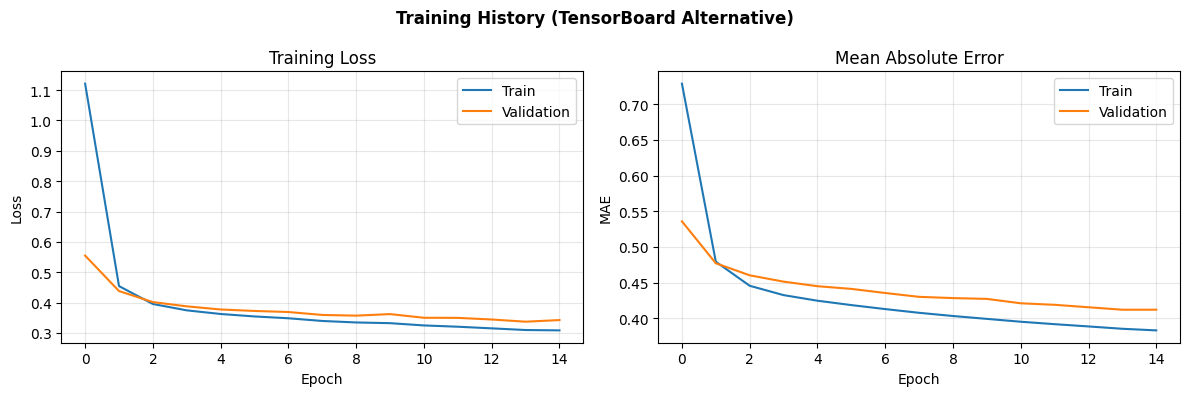

In [ ]:
# Launch TensorBoard (uncomment to run)
# %tensorboard --logdir logs/fit

# Alternative: Plot training history manually
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train')
axes[1].plot(history.history['val_mae'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Mean Absolute Error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History (TensorBoard Alternative)', fontweight='bold')
plt.tight_layout()
plt.show()

---

# Section 13: Putting It All Together

Let's create a final model that combines multiple custom components to demonstrate how they work together.

---

In [ ]:
class FullCustomModel(Model):
    """
    A model combining multiple custom components:
    - Custom layers (MyDense, Swish, AddGaussianNoise)
    - Custom normalization (MyLayerNormalization)
    - Residual connections
    """

    def __init__(self, **kwargs):
        super(FullCustomModel, self).__init__(**kwargs)

        # Custom layers
        self.dense1 = MyDense(128, activation=None)
        self.ln1 = MyLayerNormalization()
        self.swish1 = Swish()
        self.noise1 = AddGaussianNoise(stddev=0.05)

        self.dense2 = MyDense(128, activation=None)
        self.ln2 = MyLayerNormalization()
        self.swish2 = Swish()

        self.dense3 = MyDense(64, activation=None)
        self.ln3 = MyLayerNormalization()
        self.swish3 = Swish()

        self.output_dense = layers.Dense(10, activation='softmax')

    def call(self, inputs, training=None):
        # First block
        x = self.dense1(inputs)
        x = self.ln1(x)
        x = self.swish1(x)
        x = self.noise1(x, training=training)

        # Second block with residual
        residual = x
        x = self.dense2(x)
        x = self.ln2(x)
        x = self.swish2(x)
        x = x + residual  # Skip connection

        # Third block
        x = self.dense3(x)
        x = self.ln3(x)
        x = self.swish3(x)

        # Output
        return self.output_dense(x)


# Train the full custom model on Fashion-MNIST
print("Training Full Custom Model on Fashion-MNIST")
print("=" * 50)

# Create and compile model
full_model = FullCustomModel()
full_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train with OneCycle LR
steps_per_epoch = len(X_train_f) // 128
onecycle = OneCycleLR(
    max_lr=0.01,
    steps_per_epoch=steps_per_epoch,
    epochs=15
)

history = full_model.fit(
    X_train_f, y_train_f,
    epochs=15,
    batch_size=128,
    validation_data=(X_val_f, y_val_f),
    callbacks=[onecycle],
    verbose=1
)

# Evaluate
test_loss, test_acc = full_model.evaluate(X_test_f, y_test_f, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

Training Full Custom Model on Fashion-MNIST
Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8072 - loss: 0.5519 - val_accuracy: 0.8446 - val_loss: 0.4119 - lr: 0.0025
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8561 - loss: 0.3900 - val_accuracy: 0.8626 - val_loss: 0.3775 - lr: 0.0047
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8659 - loss: 0.3612 - val_accuracy: 0.8642 - val_loss: 0.3773 - lr: 0.0068
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8744 - loss: 0.3403 - val_accuracy: 0.8605 - val_loss: 0.3816 - lr: 0.0089
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8803 - loss: 0.3231 - val_accuracy: 0.8707 - val_loss: 0.3592 - lr: 0.0099
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8860 - loss: 0.3088 - val_accuracy: 0.8717 - val_loss: 0.3573 - lr: 0.0095
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8921 - loss: 0.2884 - val_accuracy: 0.8738

---

# Summary

In this notebook, we implemented the following custom components:

| Component | Implementation | Key Insight |
|-----------|---------------|-------------|
| **LR Schedulers** | OneCycleLR, WarmupExponentialDecay | Control training dynamics |
| **Dropout** | MCAlphaDropout | Uncertainty estimation with SELU |
| **Normalization** | MaxNormDense, LayerNorm | Regularization and stability |
| **Loss Functions** | HuberLoss, FocalLoss | Robustness and class imbalance |
| **Activations** | LeakyReLU, Swish, Mish | Better gradient flow |
| **Initializers** | Glorot, Orthogonal | Proper weight initialization |
| **Constraints** | PositiveWeights, UnitNorm | Weight regularization |
| **Metrics** | HuberMetric, F1Score | Track specific quantities |
| **Layers** | MyDense, GaussianNoise, etc. | Reusable computations |
| **Models** | ResidualRegressor | Complex architectures |
| **Optimizers** | MyMomentumOptimizer | Custom optimization |
| **TensorBoard** | Custom callbacks | Training visualization |

---

In [ ]:
print("\n" + "="*70)
print("NOTEBOOK 3: ADVANCED KERAS CUSTOMIZATIONS - COMPLETE")
print("="*70)
print("""
This notebook demonstrated how to build neural network components
from scratch in TensorFlow/Keras. Key takeaways:

1. Custom components give you complete control over your models
2. Understanding internals helps debug and improve performance
3. Most components follow a simple pattern:
   - __init__: Store configuration
   - build: Create weights
   - call: Define forward pass
   - get_config: Enable serialization

4. TensorBoard integration helps monitor and debug training
5. Combining custom components creates powerful, flexible models
""")
print("="*70)


NOTEBOOK 3: ADVANCED KERAS CUSTOMIZATIONS - COMPLETE

This notebook demonstrated how to build neural network components
from scratch in TensorFlow/Keras. Key takeaways:

1. Custom components give you complete control over your models
2. Understanding internals helps debug and improve performance
3. Most components follow a simple pattern:
   - __init__: Store configuration
   - build: Create weights
   - call: Define forward pass
   - get_config: Enable serialization

4. TensorBoard integration helps monitor and debug training
5. Combining custom components creates powerful, flexible models

